# LDSTOP Method: Applied to observables of Markov jump processes

This notebook accompanies the article **Stochastic optimisation method for estimating large deviations**.  
It demonstrates how the LDSTOP method can be used to estimate the large deviations of general observables of Markov jump processes.

**Author:** Daniël W. H. Cloete  
**Date:** September 2026  
**Environment:** Python 3.12.3 (see `requirements.txt` / `runtime.txt`)

### Required packages download

In [ ]:
%pip install -r ../requirements.txt

### Imports

In [1]:
# plotting
%config InlineBackend.figure_format = 'svg'
import matplotlib.pyplot as plt
colors = ['#1f77b4', '#318c31', '#d62728']

# general
import numpy as np
import copy
from tqdm import tqdm

# torch
import torch
from torch.distributions import Multinomial, Exponential
torch.set_default_dtype(torch.float64)

### LDSTOP method

In [3]:
def ldstop_MarkovJump(W, nu, make_Pi_theta, make_nu_theta, theta_x, theta_t, x0, f, g, k_min, k_max, delta_k, n, m, N, M, alpha):
    """
    Parameters:
        W             (torch.tensor): original process transition rate matrix
        nu            (torch.tensor): original process escape rate vector
        make_Pi_theta (function):     function returning controlled transition matrix using theta
        make_nu_theta (function):     function returning controlled escape rate vector using theta
        theta_x       (torch.tensor): transition parameter set with requires_grad=True
        theta_t       (torch.tensor): escape parameter set with requires_grad=True
        x0            (int):          initial state
        f             (function):     density-type function in observable definition
        g             (function):     current-type function in observable definition
        k_min         (float):        minimum k value
        k_max         (float):        maximum k value
        delta_k       (float):        k value increment
        n             (int):          number of independent parallel trajectories per epoch
        m             (int):          number of jumps for each trajectory
        N             (int):          number of optimization epochs per k value
        M             (int):          number of final epochs estimates to construct final approximations
        alpha         (float):        initial learning rate for Adagrad optimizer

    Returns:
        I_est        (float array):       final rate function estimates
        A_est        (float array):       final observable value estimates
        SCGF_est     (float array):       final SCGF estimates
        ks           (float array):       corresponding k values
        theta_star_x (torch.tensor list): optimal transition parameter values
        theta_star_t (torch.tensor list): optimal escape parameter values
        As           (float array):       observable estimates over each optimization
        Ks           (float array):       KL divergence estimates over each optimization
        Ls           (float array):       loss estimates over each optimization
    """
    # number of k values
    num_ks = int(round(k_max/delta_k, 10)) + int(round(-k_min/delta_k, 10)) + 1
    # final estimate arrays
    I_est, A_est, SCGF_est, ks = np.zeros(num_ks), np.zeros(num_ks), np.zeros(num_ks), np.zeros(num_ks)
    theta_star_x, theta_star_t = [], []
    # estimate tracking arrays
    As, Ks, Ls = np.zeros((num_ks, N)), np.zeros((num_ks, N)), np.zeros((num_ks, N))

    # initial k value
    k = 0
    k_index = 0

    # initial state
    x = torch.tensor(x0).repeat(n)

    # progress bar
    with tqdm(total=num_ks * N) as pbar:
        # k = 0 and positive k loop
        while k <= k_max:
            # average loss for baseline in score gradient
            L_ave = 0
            # adagrad optimizer for theta
            optimizer_x = torch.optim.Adagrad([theta_x], lr = alpha)
            optimizer_t = torch.optim.Adagrad([theta_t], lr = alpha)

            for epoch in range(N):
                # arrays to track estimates, transition probabilities, trajectories
                A_t, K_t = torch.zeros(m, len(x)), torch.zeros(m, len(x))
                PTs = [None] * m
                Xis = [None] * m
                dts = torch.zeros(m, len(x))
                t = torch.zeros_like(x, dtype=torch.float64)

                # generate n independent parallel trajectories using theta
                Pi_theta = make_Pi_theta(theta_x)
                nu_theta = make_nu_theta(theta_t)
                for i in range(m):
                    # residence time
                    r_pt = Exponential(nu_theta[x])
                    dt = r_pt.rsample((1,)).squeeze()
                    t += dt
                    dts[i] = dt
                    # next state
                    pt = Multinomial(1, Pi_theta[x])
                    x_i = pt.sample((1,))
                    PTs[i] = pt
                    Xis[i] = x_i
                    x1 = torch.argmax(x_i, dim=2).squeeze(0)
                    # loss
                    A = dt * f(x) + g(x, x1)
                    K = torch.log(Pi_theta[x, x1] * nu_theta[x] / W[x, x1]) - dt * (nu_theta[x] - nu[x])
                    x = x1
                    A_t[i] = A
                    K_t[i] = K
                
                # score gradient computation
                grad_L_x = torch.zeros_like(theta_x)
                for i in range(m//2):
                    coef = (K_t[i:].sum(0)/(dts[i:].sum(0)) - k*(A_t[i:].sum(0)/dts[i:].sum(0)) - L_ave).detach()
                    log_grad = torch.autograd.grad((coef * PTs[i].log_prob(Xis[i]).squeeze()).mean(), theta_x, retain_graph=True)[0]
                    grad_L_x += log_grad.clone()

                # observable, KL divergence, loss estimates
                A_T = (A_t.sum(0)/t).mean()
                K_T = (K_t.sum(0)/t).mean()
                L_T = K_T - k * A_T

                # stoch autodiff
                grad_L_t = torch.autograd.grad(L_T, theta_t, retain_graph=True)[0]

                # SGD steps
                theta_x.grad = grad_L_x
                optimizer_x.step()
                optimizer_x.zero_grad()

                theta_t.grad = grad_L_t
                optimizer_t.step()
                optimizer_t.zero_grad()

                # record estimates
                As[k_index, epoch] = A_T.detach()
                Ks[k_index, epoch] = K_T.detach()
                Ls[k_index, epoch] = L_T.detach()

                # update average loss
                L_ave = (1-1/(epoch+1))*L_ave + (1/(epoch+1))*Ls[k_index, epoch]

                # progress bar update
                pbar.update(1)

            # final estimates averaged from last M epochs
            I_est[k_index] = np.mean(Ks[k_index, -M:])
            A_est[k_index] = np.mean(As[k_index, -M:])
            SCGF_est[k_index] = -np.mean(Ls[k_index, -M:])
            ks[k_index] = k
            theta_star_x.append(copy.deepcopy(theta_x))
            theta_star_t.append(copy.deepcopy(theta_t))

            # increment k
            k += delta_k
            k_index += 1
            k = np.round(k, 10) # corrects rounding errors

        # reinitialize k, theta, x
        k = -delta_k
        theta_x = copy.deepcopy(theta_star_x[0])
        theta_t = copy.deepcopy(theta_star_t[0])
        x = torch.tensor(x0).repeat(n)

        # negative k loop
        while k >= k_min:
            # average loss for baseline in score gradient
            L_ave = 0
            # adagrad optimizer for theta
            optimizer_x = torch.optim.Adagrad([theta_x], lr = alpha)
            optimizer_t = torch.optim.Adagrad([theta_t], lr = alpha)

            for epoch in range(N):
                # arrays to track estimates, transition probabilities, trajectories
                A_t, K_t = torch.zeros(m, len(x)), torch.zeros(m, len(x))
                PTs = [None] * m
                Xis = [None] * m
                dts = torch.zeros(m, len(x))
                t = torch.zeros_like(x, dtype=torch.float64)

                # generate n independent parallel trajectories using theta
                Pi_theta = make_Pi_theta(theta_x)
                nu_theta = make_nu_theta(theta_t)
                for i in range(m):
                    # residence time
                    r_pt = Exponential(nu_theta[x])
                    dt = r_pt.rsample((1,)).squeeze()
                    t += dt
                    dts[i] = dt
                    # next state
                    pt = Multinomial(1, Pi_theta[x])
                    x_i = pt.sample((1,))
                    PTs[i] = pt
                    Xis[i] = x_i
                    x1 = torch.argmax(x_i, dim=2).squeeze(0)
                    # loss
                    A = dt * f(x) + g(x, x1)
                    K = torch.log(Pi_theta[x, x1] * nu_theta[x] / W[x, x1]) - dt * (nu_theta[x] - nu[x])
                    x = x1
                    A_t[i] = A
                    K_t[i] = K
                
                # score gradient computation
                grad_L_x = torch.zeros_like(theta_x)
                for i in range(m//2):
                    coef = (K_t[i:].sum(0)/(dts[i:].sum(0)) - k*(A_t[i:].sum(0)/dts[i:].sum(0)) - L_ave).detach()
                    log_grad = torch.autograd.grad((coef * PTs[i].log_prob(Xis[i]).squeeze()).mean(), theta_x, retain_graph=True)[0]
                    grad_L_x += log_grad.clone()

                # observable, KL divergence, loss estimates
                A_T = (A_t.sum(0)/t).mean()
                K_T = (K_t.sum(0)/t).mean()
                L_T = K_T - k * A_T

                # stoch autodiff
                grad_L_t = torch.autograd.grad(L_T, theta_t, retain_graph=True)[0]

                # SGD steps
                theta_x.grad = grad_L_x
                optimizer_x.step()
                optimizer_x.zero_grad()

                theta_t.grad = grad_L_t
                optimizer_t.step()
                optimizer_t.zero_grad()

                # record estimates
                As[k_index, epoch] = A_T.detach()
                Ks[k_index, epoch] = K_T.detach()
                Ls[k_index, epoch] = L_T.detach()

                # update average loss
                L_ave = (1-1/(epoch+1))*L_ave + (1/(epoch+1))*Ls[k_index, epoch]

                # progress bar update
                pbar.update(1)

            # final estimates averaged from last M epochs
            I_est[k_index] = np.mean(Ks[k_index, -M:])
            A_est[k_index] = np.mean(As[k_index, -M:])
            SCGF_est[k_index] = -np.mean(Ls[k_index, -M:])
            ks[k_index] = k
            theta_star_x.append(copy.deepcopy(theta_x))
            theta_star_t.append(copy.deepcopy(theta_t))

            # decrement k
            k -= delta_k
            k_index += 1
            k = np.round(k, 10) # corrects rounding errors

    return I_est, A_est, SCGF_est, ks, theta_star_x, theta_star_t, As, Ks, Ls

### Results plotting function

In [4]:
def plot_results(I_est, A_est, SCGF_est, ks, As, Ks, Ls, I = 0, SCGF = 0):
    # figure and subplots
    fig, axs = plt.subplots(3, 2, figsize=(9, 9))
    ax1, ax2 = axs[0]
    ax3, ax4 = axs[1]
    ax5, ax6 = axs[2]

    # rate function
    ax1.scatter(A_est, I_est, color=colors[2], marker='x', zorder=2)
    if I != 0:
        a_plot = np.linspace(np.min(A_est), np.max(A_est), 1000)
        ax1.plot(a_plot, I(a_plot), color='black', zorder=1)
    ax1.set_xlabel(r'$a$')
    ax1.set_ylabel(r'$I(a)$')
    ax1.spines['bottom'].set_position(('data', 0))
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # scaled cumulant generating function
    k_min = np.min(ks)
    k_max = np.max(ks)
    ax2.scatter(ks, SCGF_est, color=colors[0], marker='x', zorder=2)
    if SCGF != 0:
        k_plot = np.linspace(k_min, k_max, 1000)
        ax2.plot(k_plot, SCGF(k_plot), color='black', zorder=1)
    ax2.set_xlabel(r'$k$')
    ax2.set_ylabel(r'$\lambda(k)$')
    ax2.spines['bottom'].set_position(('data', 0))
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    col_i = [0 if k == 0 else 1 if k > 0 else 2 for k in ks]
    alphs = [1 if k == 0 else k/k_max if k > 0 else k/k_min for k in ks]

    # observable and KL estimates
    epochs = np.arange(1, len(As[0])+1)
    for i in range(len(As)):
        ax3.plot(epochs, As[i], color=colors[col_i[i]], alpha=alphs[i])
        ax4.plot(epochs, Ks[i], color=colors[col_i[i]], alpha=alphs[i])
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel(r'$A_T$')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel(r'$K_T$')

    # loss and scaled loss
    for i in range(len(As)):
        ax5.plot(epochs, Ls[i], color=colors[col_i[i]], alpha=alphs[i])
        ax6.plot(epochs, Ls[i] + SCGF_est[i], color=colors[col_i[i]], alpha=alphs[i])
    ax5.set_xlabel('Epoch')
    ax5.set_ylabel(r'$L_T$')
    ax6.set_xlabel('Epoch')
    ax6.set_ylabel(r'Scaled $L_T$')

    fig.tight_layout(w_pad=3, rect=[0, 0, 1, 0.96])
    phi = (1 + np.sqrt(5)) / 2
    for ax in axs.flat:
        ax.set_box_aspect(1 / phi)
    return fig

### Binary Markov jump process mean state

100%|██████████| 820/820 [00:43<00:00, 18.87it/s]


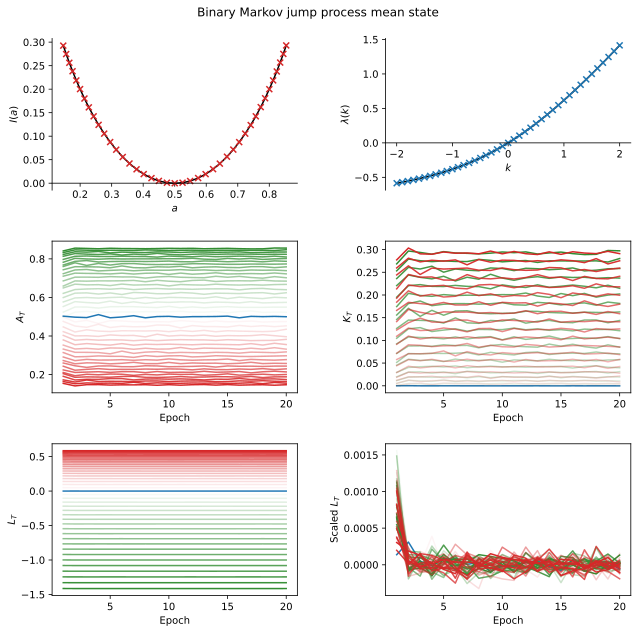

In [5]:
# problem parameters
p, q = 1.0, 1.0
W = torch.tensor([[0.0, p],[q, 0.0]])
nu = W.sum(dim=1)

def f(x):
    return x

def g(x0, x1):
    return 0

Mask = W.bool().float()

# algorithm parameters
def make_Pi_theta(theta_x):
    Pi_theta = torch.clamp(theta_x * Mask, 0.0)
    Pi_theta /= Pi_theta.sum(dim=1, keepdim=True)
    return Pi_theta

def make_nu_theta(theta_t):
    nu_theta = torch.exp(theta_t)
    return nu_theta

theta_x = W.clone().detach().requires_grad_(True)
theta_t = torch.log(nu.clone().detach()).requires_grad_(True)
x0 = 0
k_min = -2
k_max = 2
delta_k = 0.1
n = 1000
m = 50
N = 20
M = 10
alpha = 0.05

# ldstop method
I_est, A_est, SCGF_est, ks, theta_star_x, theta_star_t, As, Ks, Ls = ldstop_MarkovJump(W, nu, make_Pi_theta, make_nu_theta, theta_x, theta_t, x0, f, g, k_min, k_max, delta_k, n, m, N, M, alpha)

# true functions
def k_a(a):
    term = np.sqrt(-p * q * (a - 1) * a * (2 * a - 1)**2)
    return np.where(a < 0.5,
        -p + q + term / ((a - 1) * a),
        -p + q + term / (a - a**2),
    )

def SCGF(k):
    return 0.5 * (k - p - q + np.sqrt(4 * k * p + (-k + p + q)**2))

def I(a):
    return k_a(a)*a - SCGF(k_a(a))

# plotting
fig = plot_results(I_est, A_est, SCGF_est, ks, As, Ks, Ls, I, SCGF)
fig.suptitle('Binary Markov jump process mean state')
plt.show()

### Three-state Markov jump process mean state

100%|██████████| 1230/1230 [01:12<00:00, 17.06it/s]


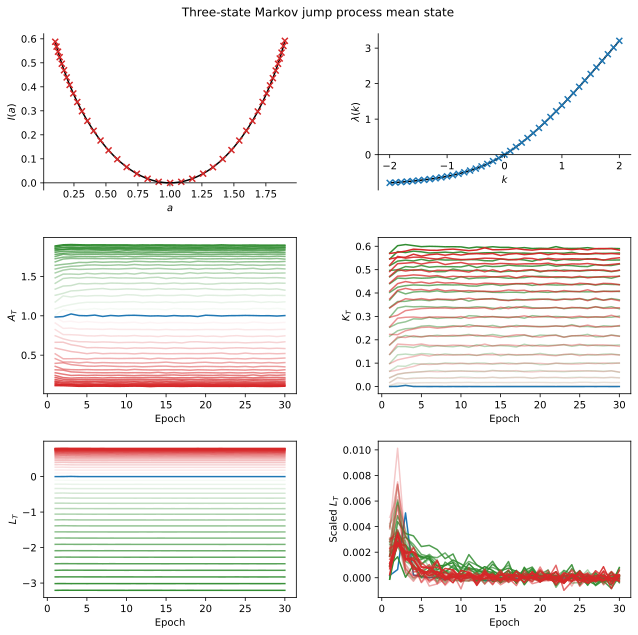

In [6]:
# problem parameters
W = torch.tensor([[0.0, 0.5, 0.5],[0.5, 0.0, 0.5],[0.5, 0.5, 0.0]])
nu = W.sum(dim=1)

def f(x):
    return x

def g(x0, x1):
    return 0

Mask = W.bool().float()

# algorithm parameters
def make_Pi_theta(theta_x):
    Pi_theta = torch.clamp(theta_x * Mask, 0.0)
    Pi_theta /= Pi_theta.sum(dim=1, keepdim=True)
    return Pi_theta

def make_nu_theta(theta_t):
    nu_theta = torch.exp(theta_t)
    return nu_theta

theta_x = W.clone().detach().requires_grad_(True)
theta_t = torch.log(nu.clone().detach()).requires_grad_(True)
x0 = 0
k_min = -2
k_max = 2
delta_k = 0.1
n = 1000
m = 50
N = 30
M = 10
alpha = 0.05

# ldstop method
I_est, A_est, SCGF_est, ks, theta_star_x, theta_star_t, As, Ks, Ls = ldstop_MarkovJump(W, nu, make_Pi_theta, make_nu_theta, theta_x, theta_t, x0, f, g, k_min, k_max, delta_k, n, m, N, M, alpha)

# true functions (approximated numerically)
state = torch.tensor([0.0, 1.0, 2.0])

def SCGF(k):
    exp_f = k * state - W.sum(dim=1)
    Lk = W + exp_f * torch.eye(len(W))
    Lk = Lk.numpy()
    eigenvalues = np.linalg.eigvals(Lk)
    dominant_eigenvalue = np.max(eigenvalues.real)
    return dominant_eigenvalue

kk = np.linspace(k_min-delta_k, k_max+delta_k, 5000)
SCGFs = [SCGF(k_i) for k_i in kk]
a_k = np.gradient(SCGFs, kk)
I_values = kk * a_k - SCGFs
sorted_indices = np.argsort(a_k)
ak = a_k[sorted_indices]
Is = I_values[sorted_indices]

def I(a):
    return np.interp(a, ak, Is)

def SCGF(k):
    return np.interp(k, kk, SCGFs)

# plotting
fig = plot_results(I_est, A_est, SCGF_est, ks, As, Ks, Ls, I, SCGF)
fig.suptitle('Three-state Markov jump process mean state')
plt.show()

### Three-state Markov jump process activity

100%|██████████| 1230/1230 [01:07<00:00, 18.09it/s]


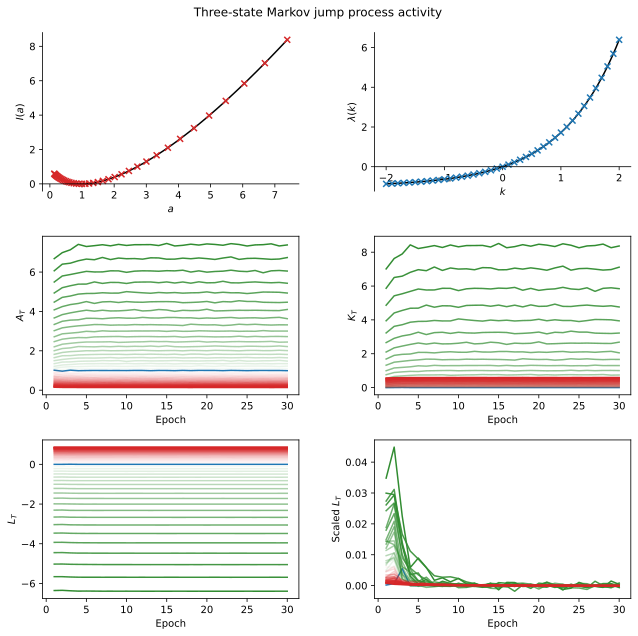

In [7]:
# problem parameters
W = torch.tensor([[0.0, 0.5, 0.5],[0.5, 0.0, 0.5],[0.5, 0.5, 0.0]])
nu = W.sum(dim=1)

def f(x):
    return 0

def g(x0, x1):
    return 1

Mask = W.bool().float()

# algorithm parameters
def make_Pi_theta(theta_x):
    Pi_theta = torch.clamp(theta_x * Mask, 0.0)
    Pi_theta /= Pi_theta.sum(dim=1, keepdim=True)
    return Pi_theta

def make_nu_theta(theta_t):
    nu_theta = torch.exp(theta_t)
    return nu_theta

theta_x = W.clone().detach().requires_grad_(True)
theta_t = torch.log(nu.clone().detach()).requires_grad_(True)
x0 = 0
k_min = -2
k_max = 2
delta_k = 0.1
n = 1000
m = 50
N = 30
M = 10
alpha = 0.05

# ldstop method
I_est, A_est, SCGF_est, ks, theta_star_x, theta_star_t, As, Ks, Ls = ldstop_MarkovJump(W, nu, make_Pi_theta, make_nu_theta, theta_x, theta_t, x0, f, g, k_min, k_max, delta_k, n, m, N, M, alpha)

# true functions (approximated numerically)
state = torch.tensor([0.0, 1.0, 2.0])

def SCGF(k):
    exp_f = k * f(state) - W.sum(dim=1)
    exp_g = np.exp(k * g(state,state))
    Lk = W * exp_g + exp_f * torch.eye(len(W))
    Lk = Lk.numpy()
    eigenvalues = np.linalg.eigvals(Lk)
    dominant_eigenvalue = np.max(eigenvalues.real)
    return dominant_eigenvalue

kk = np.linspace(k_min-delta_k, k_max+delta_k, 5000)
SCGFs = [SCGF(k_i) for k_i in kk]
a_k = np.gradient(SCGFs, kk)
I_values = kk * a_k - SCGFs
sorted_indices = np.argsort(a_k)
ak = a_k[sorted_indices]
Is = I_values[sorted_indices]

def I(a):
    return np.interp(a, ak, Is)

def SCGF(k):
    return np.interp(k, kk, SCGFs)

# plotting
fig = plot_results(I_est, A_est, SCGF_est, ks, As, Ks, Ls, I, SCGF)
fig.suptitle('Three-state Markov jump process activity')
plt.show()